In [6]:
import yfinance as yf
import pyfolio as pf



d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [7]:
data=yf.Ticker('GS').history('max')

In [8]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1999-05-04 00:00:00-04:00,52.083943,52.940587,47.972053,48.229046,22320900,0.0,0.0
1999-05-05 00:00:00-04:00,47.886408,47.886408,45.402140,47.372421,7565700,0.0,0.0
1999-05-06 00:00:00-04:00,46.601453,47.543761,45.958969,46.558620,2905700,0.0,0.0
1999-05-07 00:00:00-04:00,46.558615,51.312990,45.744803,50.799004,4862300,0.0,0.0
1999-05-10 00:00:00-04:00,50.285007,50.370671,48.143397,48.443222,2589400,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-21 00:00:00-04:00,1070.069946,1088.479980,1063.000000,1085.560059,1718600,0.0,0.0
2026-07-22 00:00:00-04:00,1078.520020,1106.660034,1078.000000,1098.199951,1538700,0.0,0.0
2026-07-23 00:00:00-04:00,1072.520020,1084.729980,1062.479980,1074.719971,1852700,0.0,0.0


In [11]:
# Calculate the daily percentage return based on changes in the closing price
returns = data.Close.pct_change()
returns

Date
1999-05-04 00:00:00-04:00         NaN
1999-05-05 00:00:00-04:00   -0.017762
1999-05-06 00:00:00-04:00   -0.017179
1999-05-07 00:00:00-04:00    0.091076
1999-05-10 00:00:00-04:00   -0.046375
                               ...   
2026-07-21 00:00:00-04:00    0.028938
2026-07-22 00:00:00-04:00    0.011644
2026-07-23 00:00:00-04:00   -0.021380
2026-07-27 00:00:00-04:00   -0.024648
2026-07-28 00:00:00-04:00   -0.007517
Name: Close, Length: 6849, dtype: float64

In [13]:
# Download SPY as the S&P 500 benchmark and calculate its daily returns
bench=yf.Ticker('SPY').history('max')
bench_returns = bench.Close.pct_change()
bench_returns

Date
1993-01-29 00:00:00-05:00         NaN
1993-02-01 00:00:00-05:00    0.007112
1993-02-02 00:00:00-05:00    0.002118
1993-02-03 00:00:00-05:00    0.010571
1993-02-04 00:00:00-05:00    0.004184
                               ...   
2026-07-22 00:00:00-04:00   -0.001163
2026-07-23 00:00:00-04:00   -0.012349
2026-07-24 00:00:00-04:00    0.001016
2026-07-27 00:00:00-04:00    0.000217
2026-07-28 00:00:00-04:00    0.002652
Name: Close, Length: 8430, dtype: float64

In [15]:
# Align the asset and benchmark returns using their shared trading dates
returns,bench_returns=returns.align(bench_returns,join='inner')


In [16]:
returns

Date
1999-05-04 00:00:00-04:00         NaN
1999-05-05 00:00:00-04:00   -0.017762
1999-05-06 00:00:00-04:00   -0.017179
1999-05-07 00:00:00-04:00    0.091076
1999-05-10 00:00:00-04:00   -0.046375
                               ...   
2026-07-21 00:00:00-04:00    0.028938
2026-07-22 00:00:00-04:00    0.011644
2026-07-23 00:00:00-04:00   -0.021380
2026-07-27 00:00:00-04:00   -0.024648
2026-07-28 00:00:00-04:00   -0.007517
Name: Close, Length: 6849, dtype: float64

In [17]:
bench_returns

Date
1999-05-04 00:00:00-04:00   -0.014279
1999-05-05 00:00:00-04:00    0.007944
1999-05-06 00:00:00-04:00   -0.006143
1999-05-07 00:00:00-04:00    0.007580
1999-05-10 00:00:00-04:00   -0.004976
                               ...   
2026-07-21 00:00:00-04:00    0.008341
2026-07-22 00:00:00-04:00   -0.001163
2026-07-23 00:00:00-04:00   -0.012349
2026-07-27 00:00:00-04:00    0.000217
2026-07-28 00:00:00-04:00    0.002652
Name: Close, Length: 6849, dtype: float64

d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.27%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '40.044%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11.964%' has dtype incompatible wit

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,78.84,2007-10-31,2008-11-20,2016-12-01,2372
1,54.59,2000-09-11,2002-10-09,2005-11-01,1342
2,48.75,2018-03-12,2020-03-23,2020-12-28,731
3,42.38,2000-03-24,2000-05-26,2000-08-28,112
4,32.84,2021-11-02,2022-06-17,2024-03-20,622


d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"]

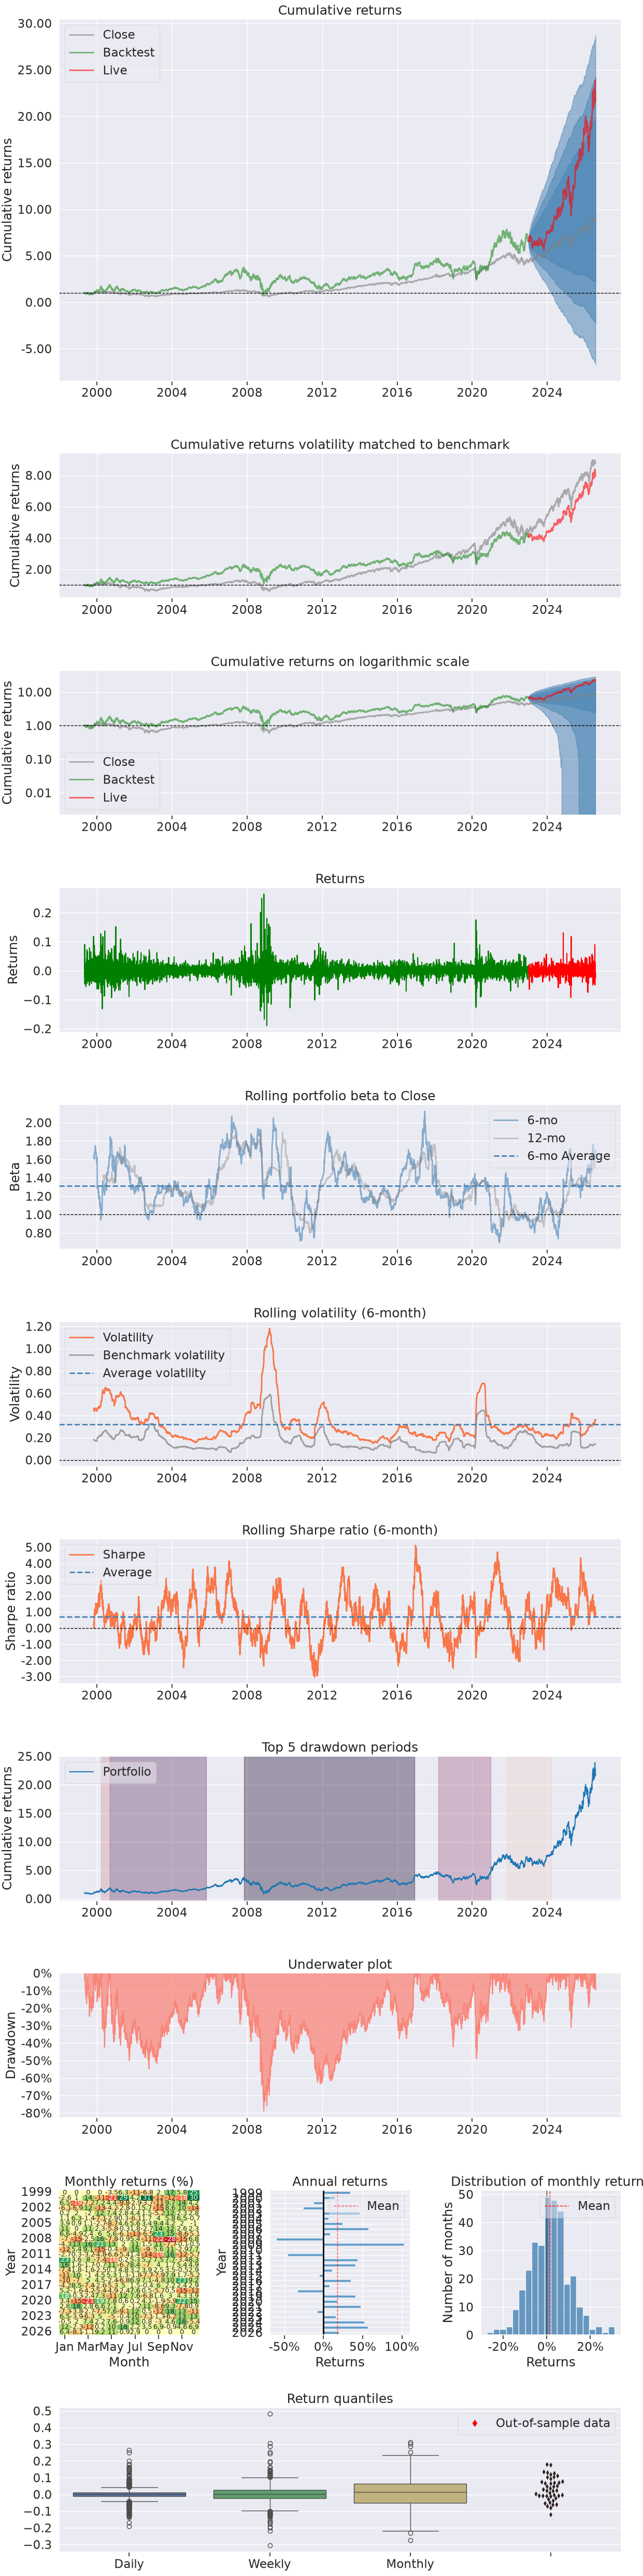

In [ ]:
# Create a tear sheet to analyze the performance of the asset returns against the benchmark returns
pf.create_returns_tear_sheet(returns,live_start_date='2023-01-01',benchmark_rets=bench_returns)

In [ ]:
import pandas as pd
tickers=['NVDA','GS','MSFT']
# how much of my portfolio is allocated to each stock
weights=pd.Series([0.4,0.4,0.2],index=tickers)


In [22]:
weights

NVDA    0.4
GS      0.4
MSFT    0.2
dtype: float64

In [ ]:
# Download the historical prices for each stock in the portfolio and combine them into a single DataFrame
prices=None
for t in tickers:
    h= yf.Ticker(t).history('max')[['Close']].rename(columns={'Close':t})
    prices=h if prices is None else prices.join(h,how='inner')

In [25]:
prices

,NVDA,GS,MSFT
Date,,,
1999-05-04 00:00:00-04:00,0.033147,48.229057,23.736761
1999-05-05 00:00:00-04:00,0.033862,47.372433,24.059843
1999-05-06 00:00:00-04:00,0.033207,46.558605,23.698755
1999-05-07 00:00:00-04:00,0.033385,50.799004,24.040836
1999-05-10 00:00:00-04:00,0.033385,48.443233,24.230888
...,...,...,...
2026-07-21 00:00:00-04:00,207.289993,1085.560059,397.750000
2026-07-22 00:00:00-04:00,212.059998,1098.199951,390.339996
2026-07-23 00:00:00-04:00,208.759995,1074.719971,381.579987


In [ ]:
# Calculate the daily percentage return for each stock in the portfolio and drop any rows with missing values
asset_ret = prices.pct_change().dropna()

In [27]:
# Calculate the daily percentage return of the portfolio based on the weighted returns of each stock 
returns=asset_ret.mul(weights).sum(axis=1)


In [28]:
returns

Date
1999-05-05 00:00:00-04:00    0.004248
1999-05-06 00:00:00-04:00   -0.017618
1999-05-07 00:00:00-04:00    0.041469
1999-05-10 00:00:00-04:00   -0.016969
1999-05-11 00:00:00-04:00    0.021544
                               ...   
2026-07-21 00:00:00-04:00    0.017209
2026-07-22 00:00:00-04:00    0.010136
2026-07-23 00:00:00-04:00   -0.019265
2026-07-27 00:00:00-04:00   -0.029390
2026-07-28 00:00:00-04:00   -0.002480
Length: 6848, dtype: float64

In [30]:
bench_returns=bench.Close.pct_change()
returns,bench_returns=returns.align(bench_returns,join='inner')

In [31]:
returns

Date
1999-05-05 00:00:00-04:00    0.004248
1999-05-06 00:00:00-04:00   -0.017618
1999-05-07 00:00:00-04:00    0.041469
1999-05-10 00:00:00-04:00   -0.016969
1999-05-11 00:00:00-04:00    0.021544
                               ...   
2026-07-21 00:00:00-04:00    0.017209
2026-07-22 00:00:00-04:00    0.010136
2026-07-23 00:00:00-04:00   -0.019265
2026-07-27 00:00:00-04:00   -0.029390
2026-07-28 00:00:00-04:00   -0.002480
Length: 6848, dtype: float64

d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '21.748%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '62.585%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '26.428%' has dtype incompatible w

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,75.04,2007-10-31,2008-11-20,2014-08-26,1780
1,67.13,2002-01-04,2002-10-09,2005-11-02,999
2,45.06,2000-09-01,2000-12-21,2001-04-20,166
3,44.02,2021-11-24,2022-10-14,2023-05-25,392
4,39.66,2018-09-04,2018-12-24,2019-12-16,335


d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:1391: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.swarmplot(
d:\portfoilio analysis project\.venv-1\Lib\site-packages\pyfolio\plotting.py:1407: UserWarning: set_ticklabels() should o

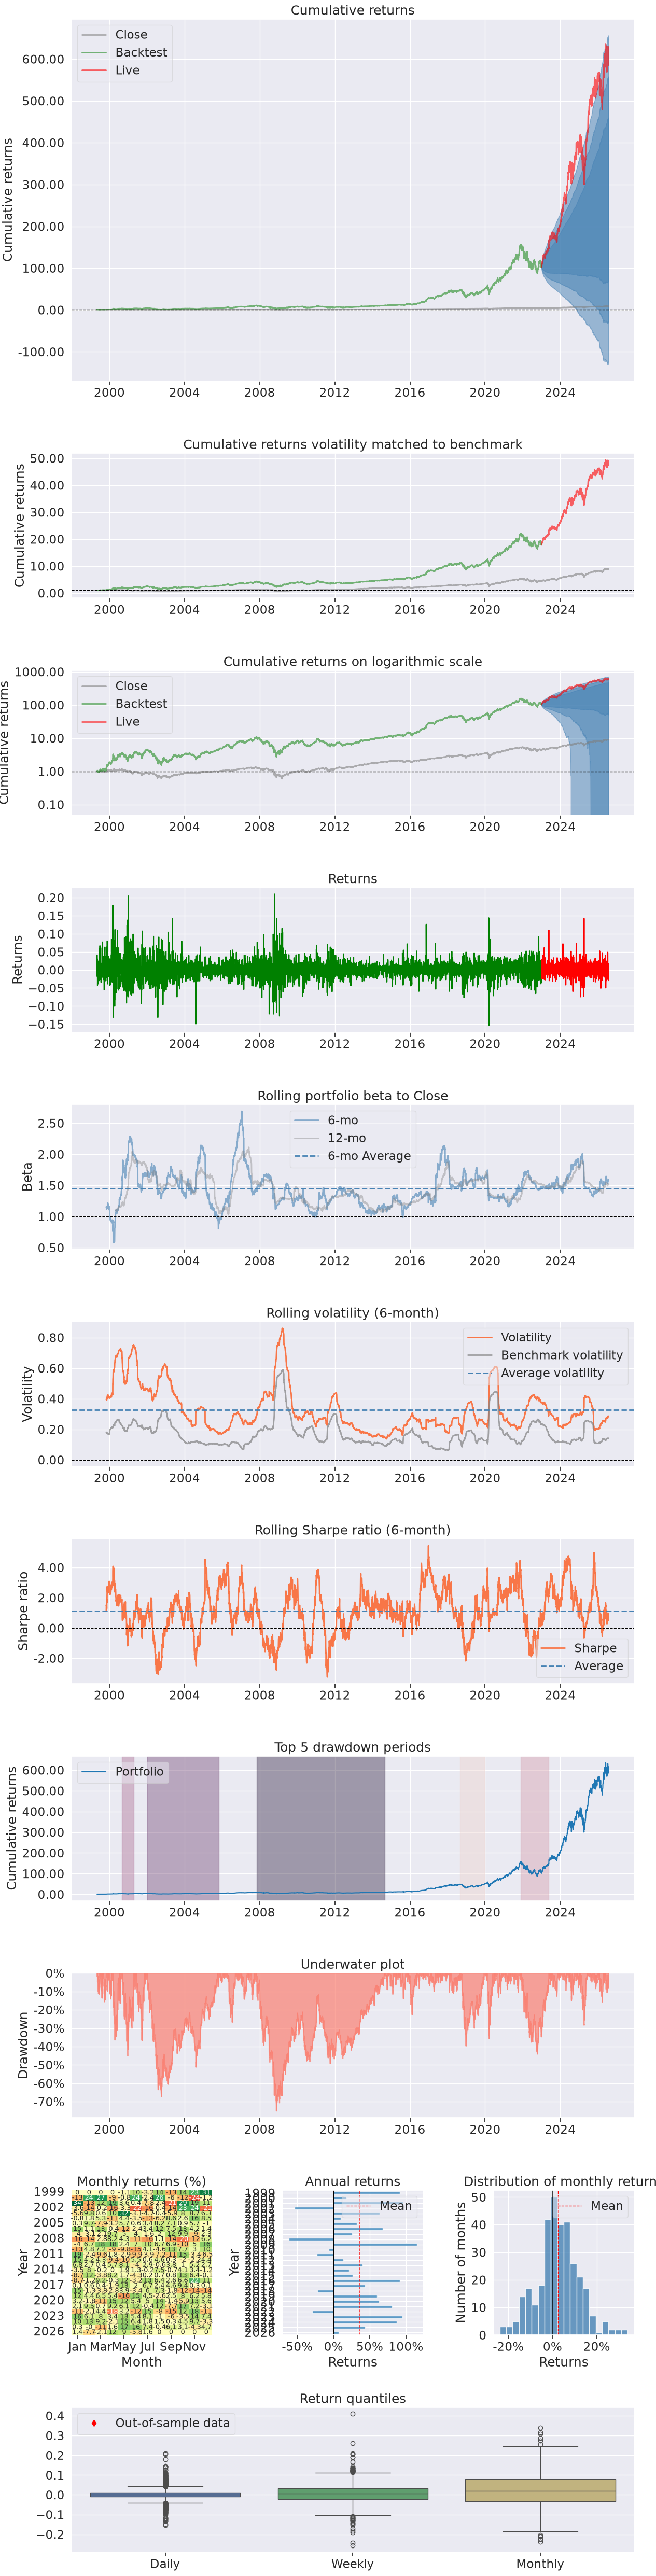

In [32]:
# Create a tear sheet to analyze the performance of the portfolio returns against the benchmark returns 
pf.create_returns_tear_sheet(returns, live_start_date='2023-01-01', benchmark_rets=bench_returns)